Dataset Loaded. Shape: (1054, 19)
Training Set: 737 samples
Validation Set: 158 samples
Test Set: 159 samples


/tmp/ipykernel_8445/4254417756.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=behavioral_importance, palette='magma')


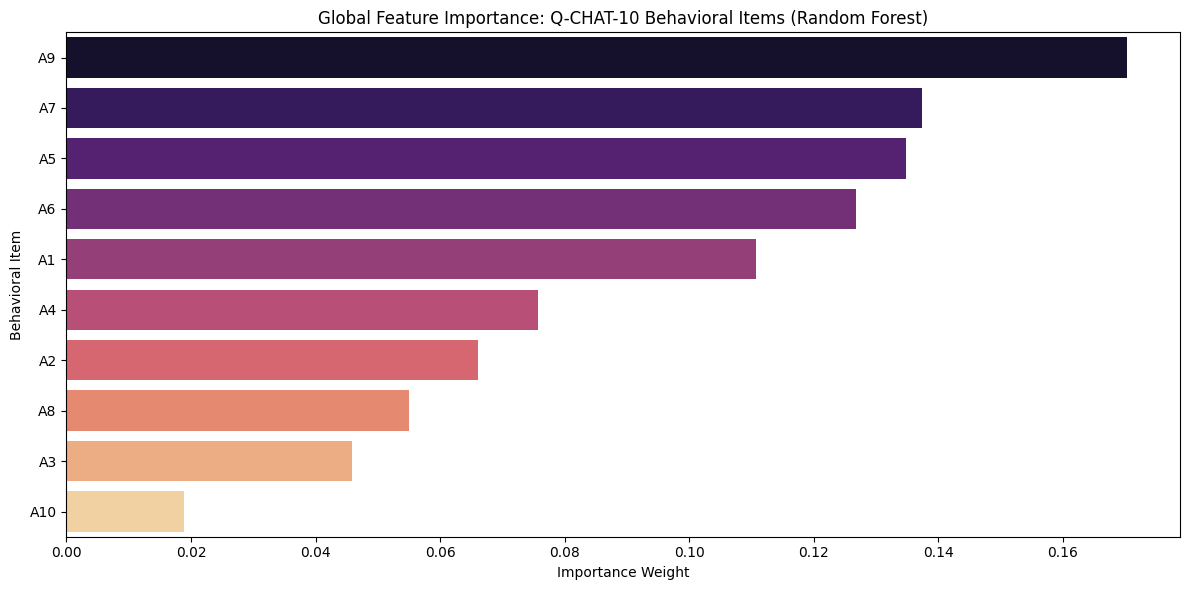


--- RANDOM FOREST TOP 5 BEHAVIORAL PREDICTORS ---
  Feature  Importance
8      A9    0.170265
6      A7    0.137319
4      A5    0.134826
5      A6    0.126762
0      A1    0.110645

Running secondary check with XGBoost...

--- XGBOOST TOP 5 BEHAVIORAL PREDICTORS ---
  Feature  XGB_Importance
8      A9        0.266335
4      A5        0.171662
6      A7        0.091108
1      A2        0.075816
5      A6        0.061183


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:52:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ---------------------------------------------------------
# 1. LOAD AND CLEAN THE DATASET
# ---------------------------------------------------------
# Using your exact uploaded filename
file_path = 'Toddler Autism dataset July 2018.csv'
df = pd.read_csv('/Autism_dataset.csv')

print("Dataset Loaded. Shape:", df.shape)

# Drop any rows with missing values just in case
df = df.dropna()

# ---------------------------------------------------------
# 2. PREPROCESSING & FEATURE ENCODING
# ---------------------------------------------------------
# The exact target column in your dataset has a trailing space
target_col = 'Class/ASD Traits '

# Convert Target Label (Class/ASD Traits) to binary (1 = Yes, 0 = No)
df['Target'] = df[target_col].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# Columns that should NOT be used as predictive features
# Case_No is just an ID, Qchat-10-Score causes data leakage,
# 'Who completed the test' is administrative.
features_to_drop = [target_col, 'Target', 'Case_No', 'Qchat-10-Score', 'Who completed the test']

# Create feature matrix (X) and target vector (y)
# get_dummies will handle 'Sex', 'Ethnicity', 'Jaundice', and 'Family_mem_with_ASD' automatically
X = pd.get_dummies(df.drop(columns=features_to_drop, errors='ignore'), drop_first=True)
y = df['Target']

# ---------------------------------------------------------
# 3. DATA SPLITTING (70% Train, 15% Val, 15% Test)
# ---------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Validation Set: {X_val.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")

# ---------------------------------------------------------
# 4. TRAIN THE RANDOM FOREST MODEL
# ---------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. EXTRACT & VISUALIZE FEATURE IMPORTANCE (RF)
# ---------------------------------------------------------
importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Filter to ONLY show the behavioral questions (A1 - A10)
behavioral_importance = importance_df[importance_df['Feature'].str.contains('^A[1-9]$|^A10$', regex=True)]

# Plot the results
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=behavioral_importance, palette='magma')
plt.title('Global Feature Importance: Q-CHAT-10 Behavioral Items (Random Forest)')
plt.xlabel('Importance Weight')
plt.ylabel('Behavioral Item')
plt.tight_layout()
plt.show()

print("\n--- RANDOM FOREST TOP 5 BEHAVIORAL PREDICTORS ---")
print(behavioral_importance.head(5))

# ---------------------------------------------------------
# 6. SECONDARY CHECK: XGBOOST MODEL
# ---------------------------------------------------------
print("\nRunning secondary check with XGBoost...")
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

xgb_importances = xgb_model.feature_importances_
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'XGB_Importance': xgb_importances
}).sort_values(by='XGB_Importance', ascending=False)

xgb_behavioral = xgb_importance_df[xgb_importance_df['Feature'].str.contains('^A[1-9]$|^A10$', regex=True)]

print("\n--- XGBOOST TOP 5 BEHAVIORAL PREDICTORS ---")
print(xgb_behavioral.head(5))